In [2]:
# modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
import glob
import re
import os

In [17]:
# input data
data = np.load('combined_data_20250228_170230.npz')
#data_2 = np.load('atm_0106_data_perturbed/1013_mbar_scope_data_20250106_143102.npz')


In [18]:
print(data.files)

['pressure', 'pressure_timestamps', 'channel_1', 'channel_2', 'channel_3', 'channel_4', 'time']


In [21]:
x=data['channel_1']
y=data['channel_2']
sum=data['channel_3']
t=data['time']
# print('length of time vector is: ', len(t))
# length of time vector is defined by device: 'CHAN:DATA:POIN DEF')

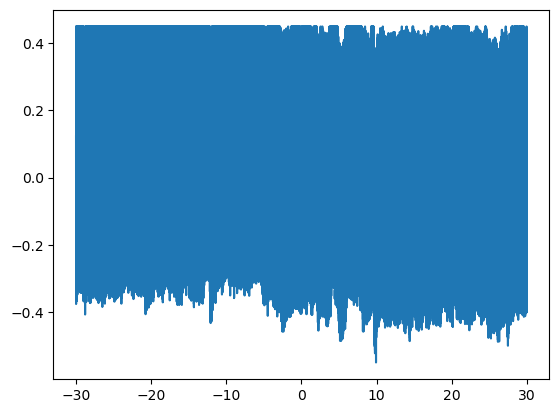

In [22]:
plt.plot(t,y)

In [23]:
# welch's method -- look up
sam_freq = 1/(t[1]-t[0]) #sampling frequency
freq, pxx = welch(x,fs=sam_freq,nperseg=2**22)
freq, pyy = welch(y,fs=sam_freq,nperseg=2**22)
print(len(x))
print(2**22)

9999360
4194304


(20.0, 40.0)

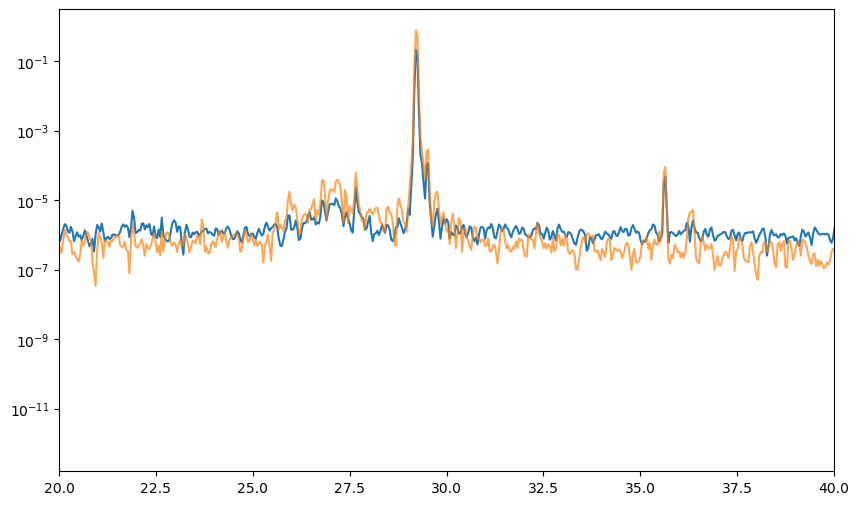

In [24]:
plt.figure(figsize=(10,6))
plt.semilogy(freq,pxx)
plt.semilogy(freq,pyy, alpha=0.7)
plt.xlim(20,40)

File: combined_data_20250228_170230.npz
Mean voltage of sum channel:  1.998000000000036
Pressure: Unknown mbar


FileNotFoundError: [Errno 2] No such file or directory: '10_mbar_scope_data_20250102_165336.npz'

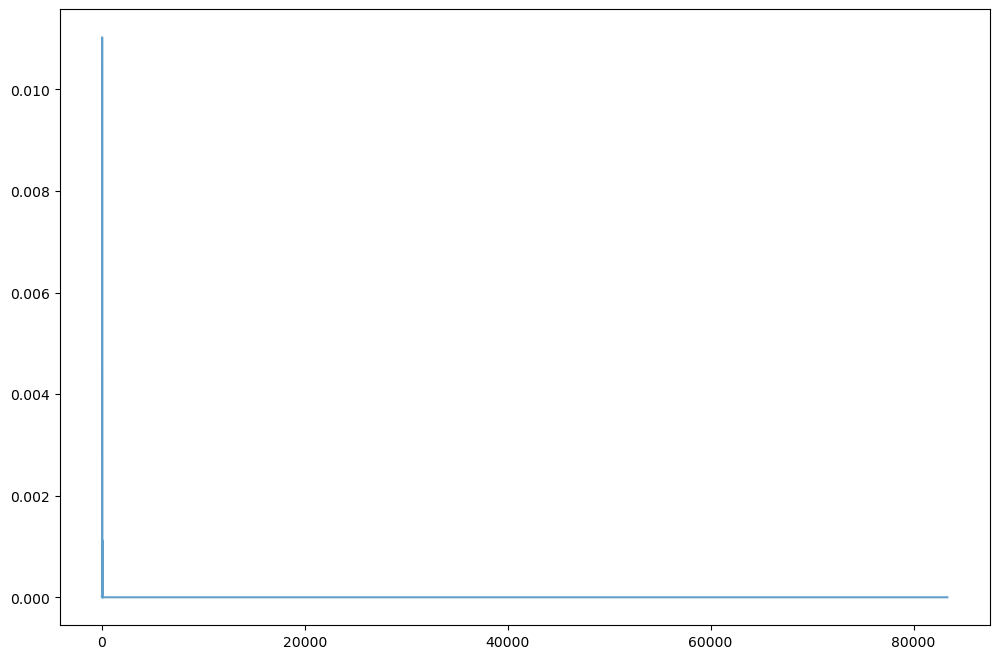

In [26]:
# Overplotting multiple single files
file_list = ['combined_data_20250228_170230.npz', '10_mbar_scope_data_20250102_165336.npz']

# initialize figure for overplotting
plt.figure(figsize=(12, 8))

for file in file_list:
    data = np.load(file)

    # extracting pressure from file name 
    match = re.match(r'(\d+)_mbar', file)
    if match:
        pressure = match.group(1)
    else:
        pressure = 'Unknown'

    x = data['channel_1']
    y = data['channel_2']
    s = data['channel_3'] 
    if 'time' in data.keys():
        t = data['time']
    else:
        t= data['t']

    print('File:', file)
    print('Mean voltage of sum channel: ', np.mean(s))
    print(f'Pressure: {pressure} mbar')

    sam_freq = 1 / (t[1] - t[0])

    freq, pxx = welch(x, fs=sam_freq, nperseg=2**16)
    _, pyy = welch(y, fs=sam_freq, nperseg=2**16)

    #plt.semilogy(freq, pxx, label=f'Pressure: {pressure} mbar (X)')
    #plt.semilogy(freq, pyy, alpha=0.7, label=f'Pressure: {pressure} mbar (Y)')
    plt.plot(freq, pyy, alpha=0.7, label=f'Pressure: {pressure} mbar (Y)')

plt.xlabel('Frequency (Hz)')
plt.xlim(22,32)
plt.ylim(0,0.0005)
plt.ylabel('Power Spectral Density (PSD)')
#plt.title('PSD')
plt.legend()
plt.grid()
plt.show()

Mean voltage of sum channel:  0.8737739742943549
Mean voltage of sum channel:  0.8700938264448922
Mean voltage of sum channel:  0.8714044749663977
Mean voltage of sum channel:  0.8715575453629033
Mean voltage of sum channel:  0.8711313902889786
Mean voltage of sum channel:  0.8717641498655914
Mean voltage of sum channel:  0.8699915112567205


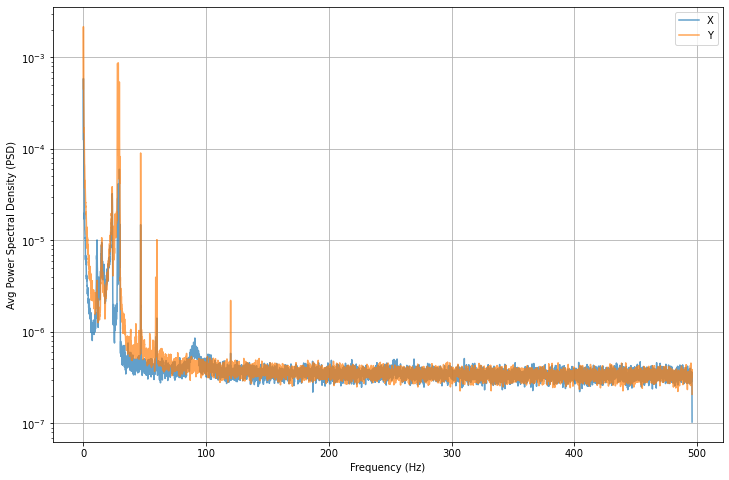

In [48]:
# Create averaged PSD npz file with option of plotting
folder_path = './1000_0_mbar_0102_data/'
# folder_path = './atm_0106_data_perturbed/'
files = glob.glob(f'{folder_path}/*.npz')

# Name npz file output by extracting folder name, create new directory for files
output_dir = 'avg_psd'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

folder_name = os.path.basename(os.path.normpath(folder_path))  # Remove trailing slashes and extract name
output_file_name = os.path.join(output_dir, f'{folder_name}_averaged_psd_14.npz')

# Initialize accumulators for PSD sums to average 
pxx_sum = None
pyy_sum = None
sam_freq = None  # Sampling frequency placeholder
freq = None      # Frequency placeholder
file_count = len(files)

plt.figure(figsize=(12, 8))

# Loop through each file and compute PSD
for file in files:
    data = np.load(file)
    x = data['channel_1']
    y = data['channel_2']
    s = data['channel_3'] 
    t = data['t']

    print('Mean voltage of sum channel: ', np.mean(s))
    
    if sam_freq is None:  # Calculate sampling frequency only once
        sam_freq = 1 / (t[1] - t[0])
    
    # Compute PSD for x and y
    freq, pxx = welch(x, fs=sam_freq, nperseg=2**14)
    _, pyy = welch(y, fs=sam_freq, nperseg=2**14)
    
    # Accumulate PSD values
    if pxx_sum is None:
        pxx_sum = pxx
        pyy_sum = pyy
    else:
        pxx_sum += pxx
        pyy_sum += pyy

# Compute average PSD
pxx_avg = pxx_sum / file_count
pyy_avg = pyy_sum / file_count

# Save averaged PSDs and frequencies
np.savez(output_file_name, freq=freq, pxx_avg=pxx_avg, pyy_avg=pyy_avg)

# Plot
plt.semilogy(freq, pxx_avg, alpha=0.7, label='X')
plt.semilogy(freq, pyy_avg, alpha=0.7, label='Y')
# plt.plot(freq, pyy, alpha=0.7, label=f'Pressure: {pressure} mbar (Y)') 

plt.xlabel('Frequency (Hz)')
#plt.xlim(10,35)
#plt.ylim(0,0.0005)
plt.ylabel('Avg Power Spectral Density (PSD)')
#plt.title('PSD')
plt.legend()
plt.grid()
plt.show()

In [14]:
class PSDPlotter:
    def __init__(self, file_list):
        self.file_list = file_list

    def extract_pressure(self, file_name):
        match = re.match(r'.*?(\d+_\d+)_mbar', file_name)
        return match.group(1).replace('_', '.') if match else 'Unknown'

    def extract_label(self, file_name, style='pressure'):
        """
        Extract labels based on the given style.
        Options: 'pressure', 'sample', 'stability'.
        """
        if style == 'pressure':
            return f'Pressure: {self.extract_pressure(file_name)} mbar'
        elif style == 'sample':
            if 'no_sample' in file_name:
                return 'No Sample'
            else:
                return 'Sample'
        elif style == 'stability':
            if 'perturbed' in file_name:
                return 'Perturbed'
            else:
                return 'Stable'
        else:
            return 'Unknown Label'

    def plot(self, label_style='pressure', include_x=False, title=None, xlim=None):
        """
        Plot the PSDs with the specified label style.
        
        Args:
        - label_style: 'pressure', 'sample', or 'stability'
        - include_x: If True, include pxx_avg in the plot
        - title: Custom title for the plot
        - xlim: Tuple specifying the x-axis limits (e.g., (0, 100)) or None for no limits
        """
        plt.figure(figsize=(10, 6))

        for file in self.file_list:
            data = np.load(file)
            freq = data['freq']
            pxx_avg = data['pxx_avg']
            pyy_avg = data['pyy_avg']

            label = self.extract_label(file, style=label_style)

            # Plot Y channel
            plt.semilogy(freq, pyy_avg, alpha=0.7, label=f'{label} (Y)')
            if include_x:
                plt.semilogy(freq, pxx_avg, alpha=0.7, label=f'{label} (X)')

        # Set plot properties
        plt.xlabel('Frequency (Hz)')
        plt.ylabel('Avg Power Spectral Density (PSD)')
        if title:
            plt.title(title)  # Add custom title
        if xlim:
            plt.xlim(xlim)  # Set x-axis limits if provided
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

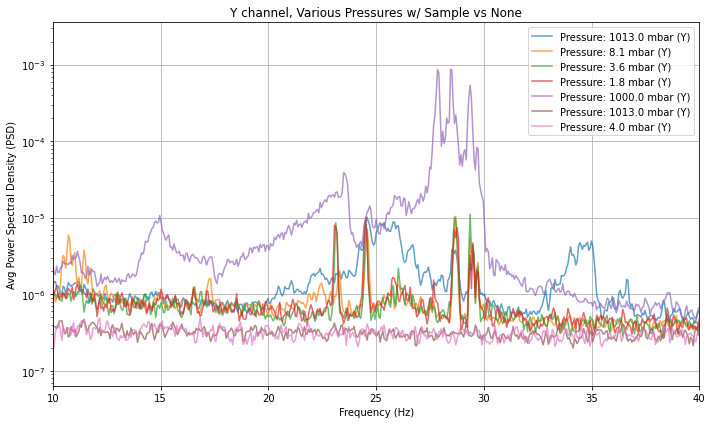

In [ ]:
# file_list = [
#     'avg_psd/1013_0_mbar_0106_data_perturbed_averaged_psd_14.npz',
#     'avg_psd/1013_0_mbar_0106_data_no_sample_perturbed_averaged_psd_14.npz'
# ]

# file_list = [
#     'avg_psd/1013_0_mbar_0106_data_perturbed_averaged_psd_14.npz',
#     'avg_psd/8_2_mbar_0106_data_perturbed_averaged_psd_14.npz',
#     'avg_psd/1013_0_mbar_0106_data_no_sample_perturbed_averaged_psd_14.npz'
# ]

file_list = [
    'avg_psd/1013_0_mbar_0106_data_averaged_psd_14.npz',
    'avg_psd/8_1_mbar_0106_data_averaged_psd_14.npz',
    'avg_psd/3_6_mbar_0106_data_averaged_psd_14.npz',    
    'avg_psd/1_8_mbar_0106_data_averaged_psd_14.npz',
    'avg_psd/1013_0_mbar_0106_data_no_sample_averaged_psd_14.npz', 
    'avg_psd/4_0_mbar_0106_data_no_sample_averaged_psd_14.npz'
]

# Initialize plotter
plotter = PSDPlotter(file_list)

# Plot comparing sample vs. no sample
plotter.plot(label_style='pressure', title='Y channel, Various Pressures w/ Sample vs None', xlim=(10,40))

File: avg_psd/1013_0_mbar_0106_data_perturbed_averaged_psd.npz
Pressure: 1013.0 mbar
File: avg_psd/1013_0_mbar_0106_data_no_sample_perturbed_averaged_psd.npz
Pressure: 1013.0 mbar


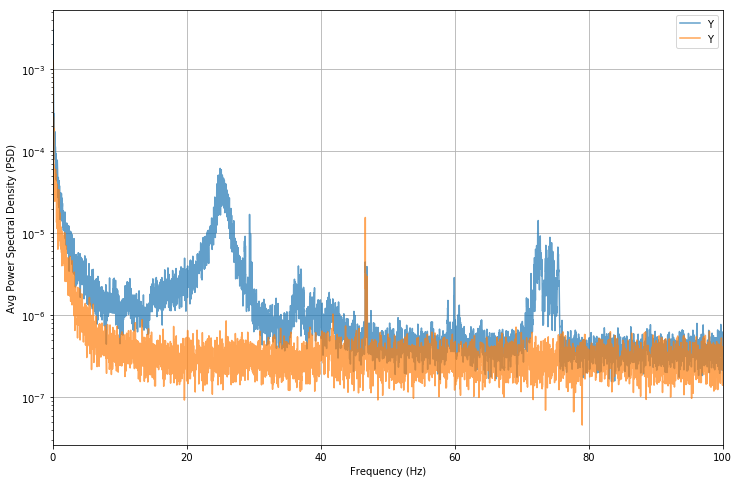

In [231]:
# Overplotting averaged files - sample vs no sample
file_list = ['avg_psd/1013_0_mbar_0106_data_perturbed_averaged_psd.npz', 'avg_psd/1013_0_mbar_0106_data_no_sample_perturbed_averaged_psd.npz']

# initialize figure for overplotting
plt.figure(figsize=(12, 8))

for file in file_list:
    data = np.load(file)
    # file_name = os.path.basename(file_list)

    # extracting pressure from file name 
    match = re.match(r'avg_psd/(\d+_\d+)_mbar', file)
    if match:
        pressure = match.group(1).replace('_', '.') 
    else:
        pressure = 'Unknown'

    freq = data['freq']
    pxx_avg = data['pxx_avg']
    pyy_avg = data['pyy_avg'] 
    #s = 

    print('File:', file)
    #print('Mean voltage of sum channel: ', np.mean(s))
    print(f'Pressure: {pressure} mbar')

    sam_freq = 1 / (t[1] - t[0])

    # plt.semilogy(freq, pxx_avg, alpha=0.7, label='(X)')
    plt.semilogy(freq, pyy_avg, alpha=0.7, label='Y')
    # plt.plot(freq, pyy, alpha=0.7, label='Y')

plt.xlabel('Frequency (Hz)')
plt.xlim(0,100)
#plt.ylim(0,0.0005)
plt.ylabel('Avg Power Spectral Density (PSD)')
#plt.title('PSD')
plt.legend()
plt.grid()
plt.show()

File: avg_psd/1013_0_mbar_0106_data_averaged_psd.npz
Pressure: 1013.0 mbar
File: avg_psd/1013_0_mbar_0106_data_perturbed_averaged_psd.npz
Pressure: 1013.0 mbar


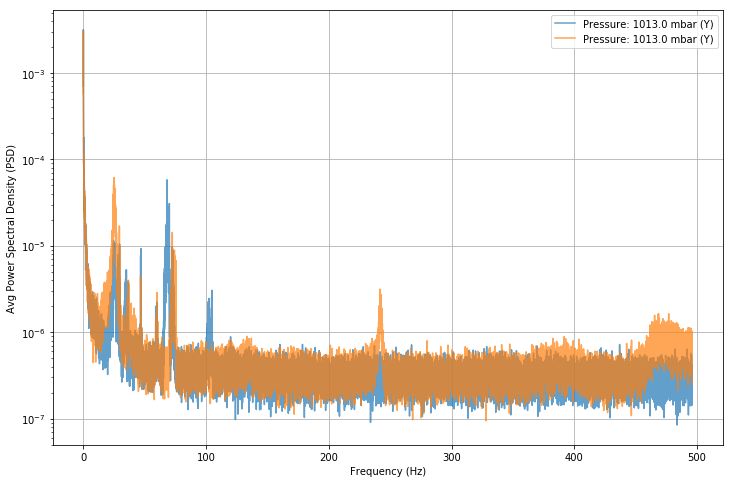

In [229]:
# Overplotting averaged single files - pressures
file_list = ['avg_psd/1013_0_mbar_0106_data_averaged_psd.npz', 'avg_psd/1013_0_mbar_0106_data_perturbed_averaged_psd.npz']

# initialize figure for overplotting
plt.figure(figsize=(12, 8))

for file in file_list:
    data = np.load(file)
    # file_name = os.path.basename(file_list)

    # extracting pressure from file name 
    match = re.match(r'avg_psd/(\d+_\d+)_mbar', file)
    if match:
        pressure = match.group(1).replace('_', '.') 
    else:
        pressure = 'Unknown'

    freq = data['freq']
    pxx_avg = data['pxx_avg']
    pyy_avg = data['pyy_avg'] 
    #s = 

    print('File:', file)
    #print('Mean voltage of sum channel: ', np.mean(s))
    print(f'Pressure: {pressure} mbar')

    sam_freq = 1 / (t[1] - t[0])

    # plt.semilogy(freq, pxx_avg, alpha=0.7, label=f'Pressure: {pressure} mbar (X)')
    plt.semilogy(freq, pyy_avg, alpha=0.7, label=f'Pressure: {pressure} mbar (Y)')
    # plt.plot(freq, pyy, alpha=0.7, label=f'Pressure: {pressure} mbar (Y)')

plt.xlabel('Frequency (Hz)')
# plt.xlim(22,32)
#plt.ylim(0,0.0005)
plt.ylabel('Avg Power Spectral Density (PSD)')
#plt.title('PSD')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# Overplotting averaged single files - non-perturbed & perturbed
file_list = ['avg_psd/1013_0_mbar_0106_data_averaged_psd.npz', 'avg_psd/1013_0_mbar_0106_data_perturbed_averaged_psd.npz']
label_list = ['Stable', 'Perturbed']
# initialize figure for overplotting
plt.figure(figsize=(12, 8))

for file in file_list:
    data = np.load(file)
    # file_name = os.path.basename(file_list)

    # extracting pressure from file name 
    match = re.match(r'avg_psd/(\d+_\d+)_mbar', file)
    if match:
        pressure = match.group(1).replace('_', '.') 
    else:
        pressure = 'Unknown'

    freq = data['freq']
    pxx_avg = data['pxx_avg']
    pyy_avg = data['pyy_avg'] 
    #s = 

    print('File:', file)
    #print('Mean voltage of sum channel: ', np.mean(s))
    print(f'Pressure: {pressure} mbar')

    sam_freq = 1 / (t[1] - t[0])

    # plt.semilogy(freq, pxx_avg, alpha=0.7, label='X')
    plt.semilogy(freq, pyy_avg, alpha=0.7, label='Y')
    # plt.plot(freq, pyy, alpha=0.7, label='Y')

plt.xlabel('Frequency (Hz)')
# plt.xlim(22,32)
#plt.ylim(0,0.0005)
plt.ylabel('Avg Power Spectral Density (PSD)')
#plt.title('PSD')
plt.legend()
plt.grid()
plt.show()